#### Problem Statement:

- Subsequence: Contiguous or non-contiguous part of array which follows an order
- Subarray: Strictly contiguous
- No. of subsequences for array of length n: 2^n (including empty array), as for each element we have 2 options either to include it or not 
- Another algo for generating all the subsequences is power set

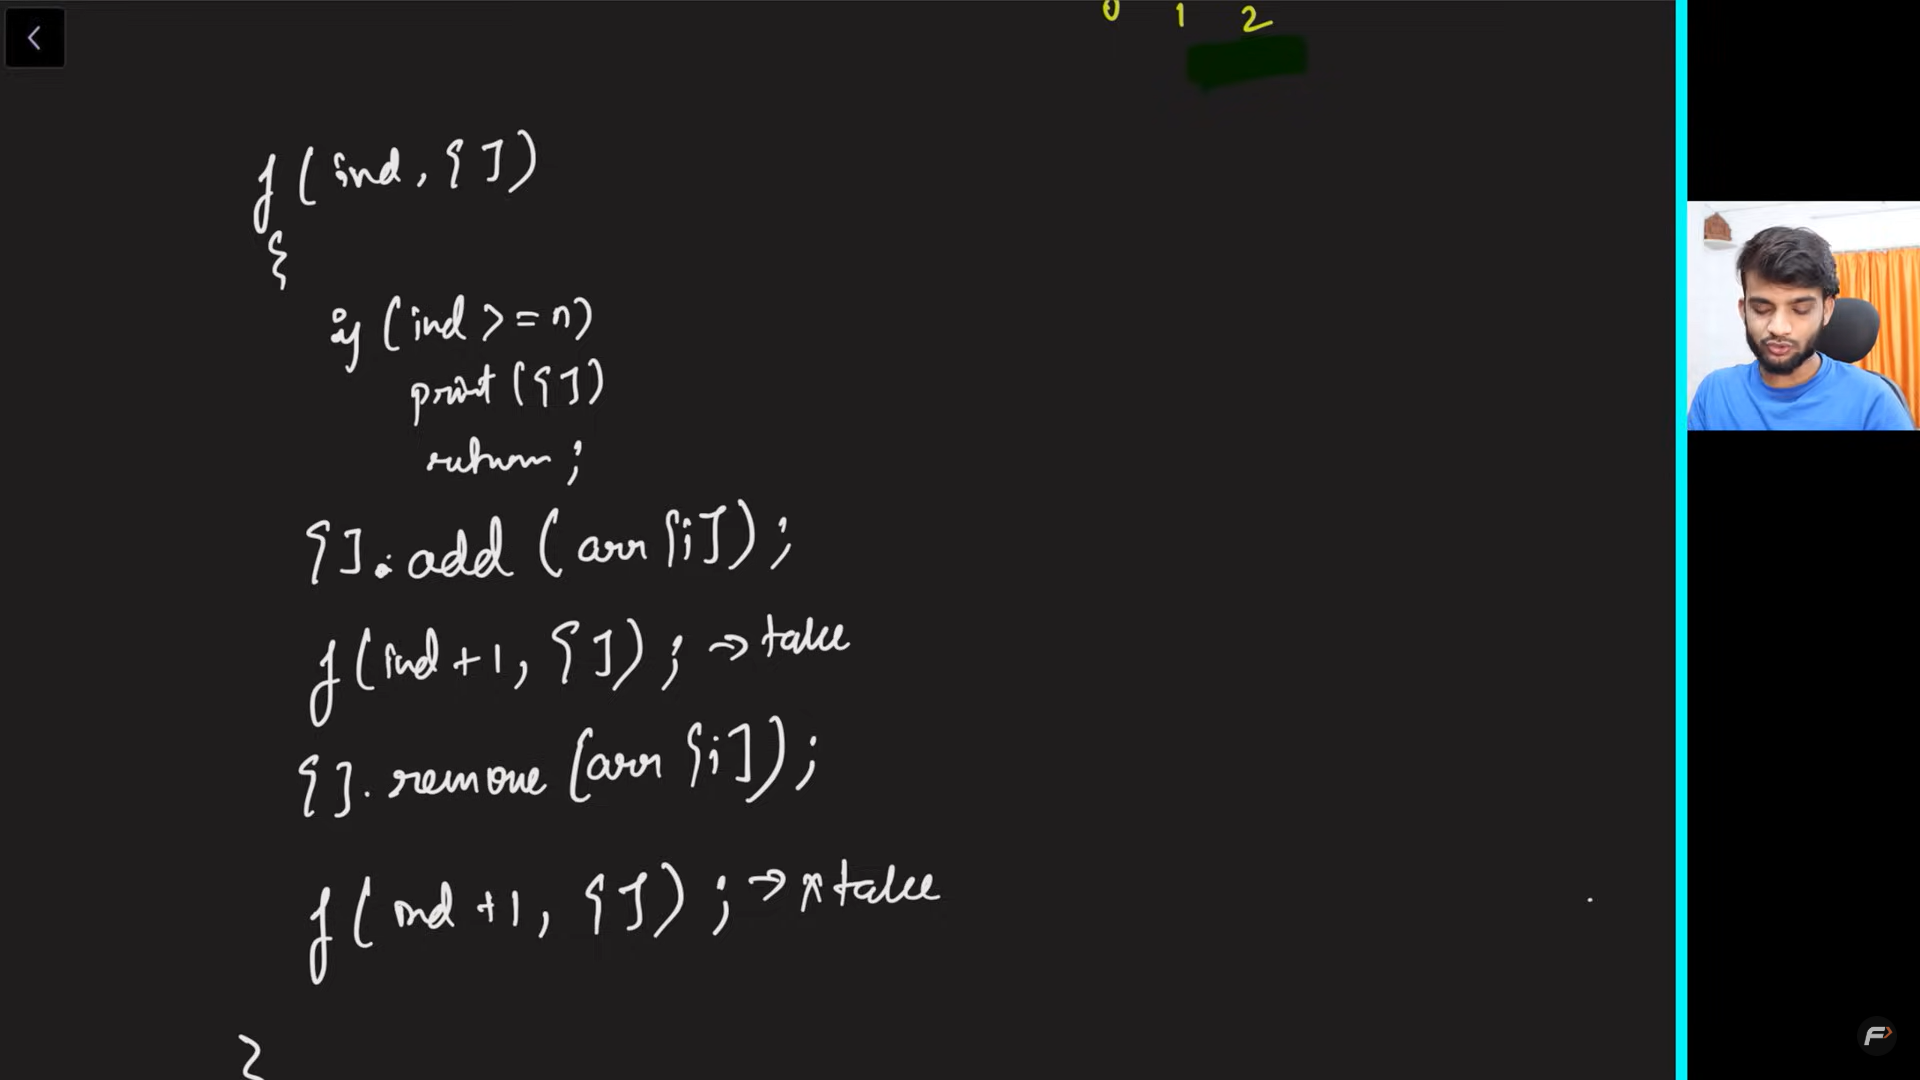

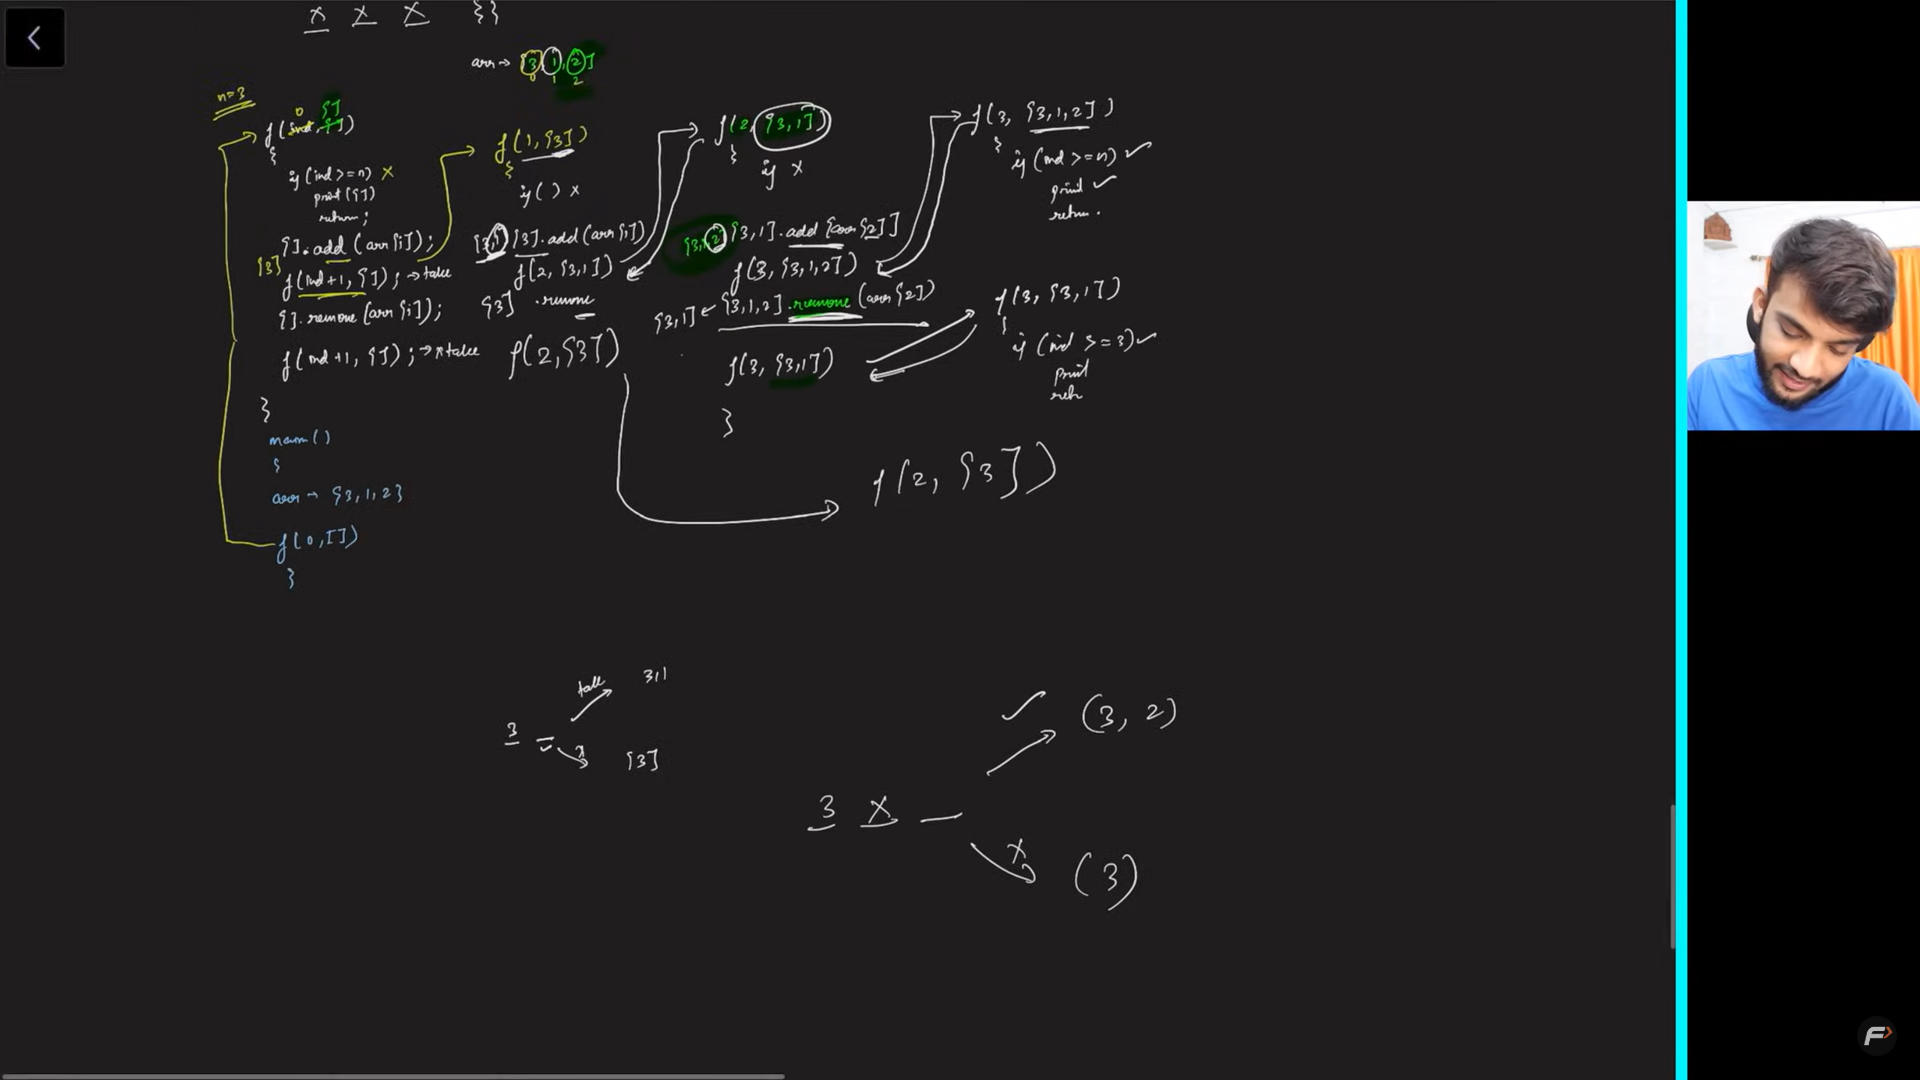

#### Recursion Tree

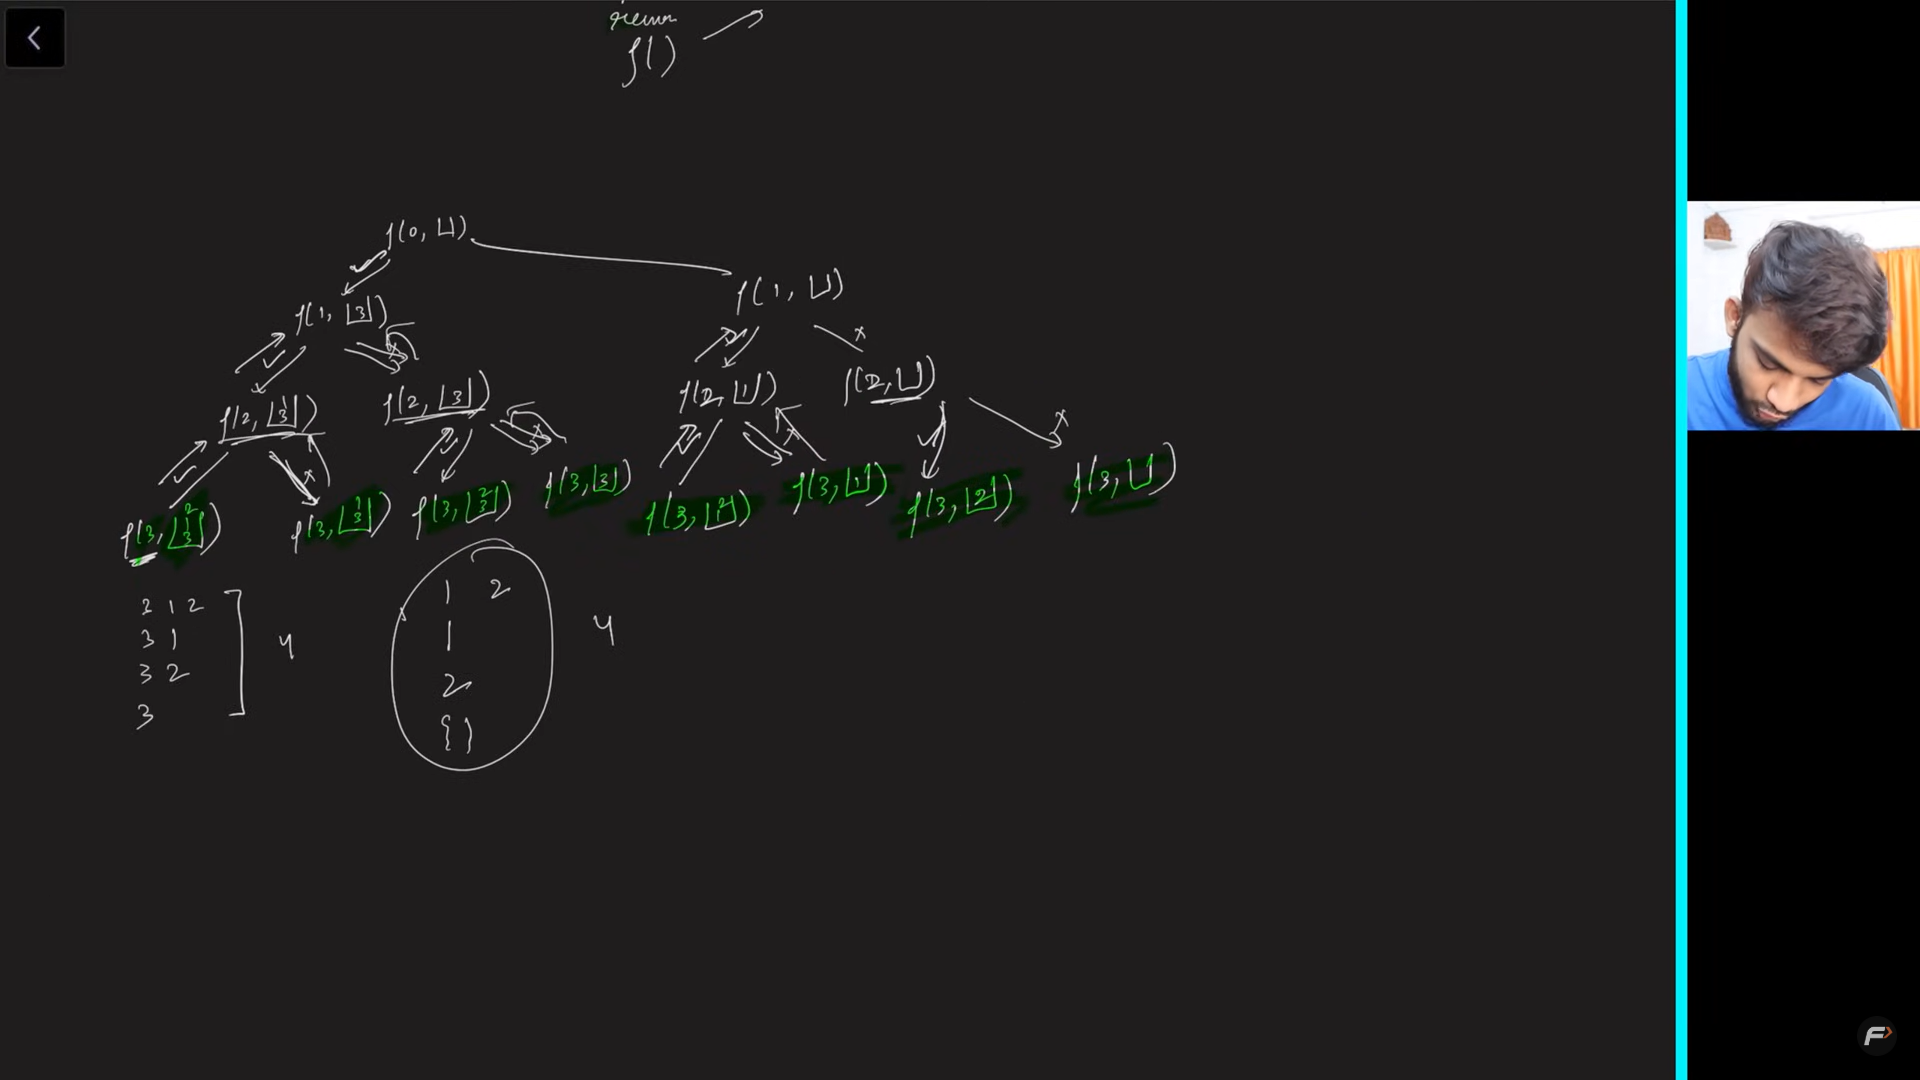

#### Intuition:
- At each index it is about taking the element present at that index or not
- Before not considering that element and moving to next index, we remove the one added (considered before)

In [12]:
def generate_subsequence(arr: list,
                         idx: int,
                         ans: list, 
                         curr: list):
    
    if ans is None:
        ans= []
    
    if curr is None:
        curr= []
        
    # base case
    if idx == len(arr):
        ans.append(curr[:]) # append a copy of curr list and not the org curr list
        return
    
    # Take the idx element (Pick)
    curr.append(arr[idx])
    generate_subsequence(arr, idx+1, ans, curr)
    curr.remove(arr[idx])   # backtrack (undo the change of appending the element)
    
    # remove the element so that it can be considered as not take case (Not pick)
    generate_subsequence(arr, idx+1, ans, curr)     # move to the next array index
    
    return ans

In [13]:
arr = [1, 2, 3]
all_subs = generate_subsequence(arr, idx=0, ans= None, curr= None)
all_subs

[[1, 2, 3], [1, 2], [1, 3], [1], [2, 3], [2], [3], []]

#### 2. Printing subsequence whose sum equals to a target

- Check the base case where idx reaches the len of array and sum equals target
- Otherwise pick for the next idx, add the idx element to sum
- Remove the element from the list, remove the element from sum
- Go for the not pick case

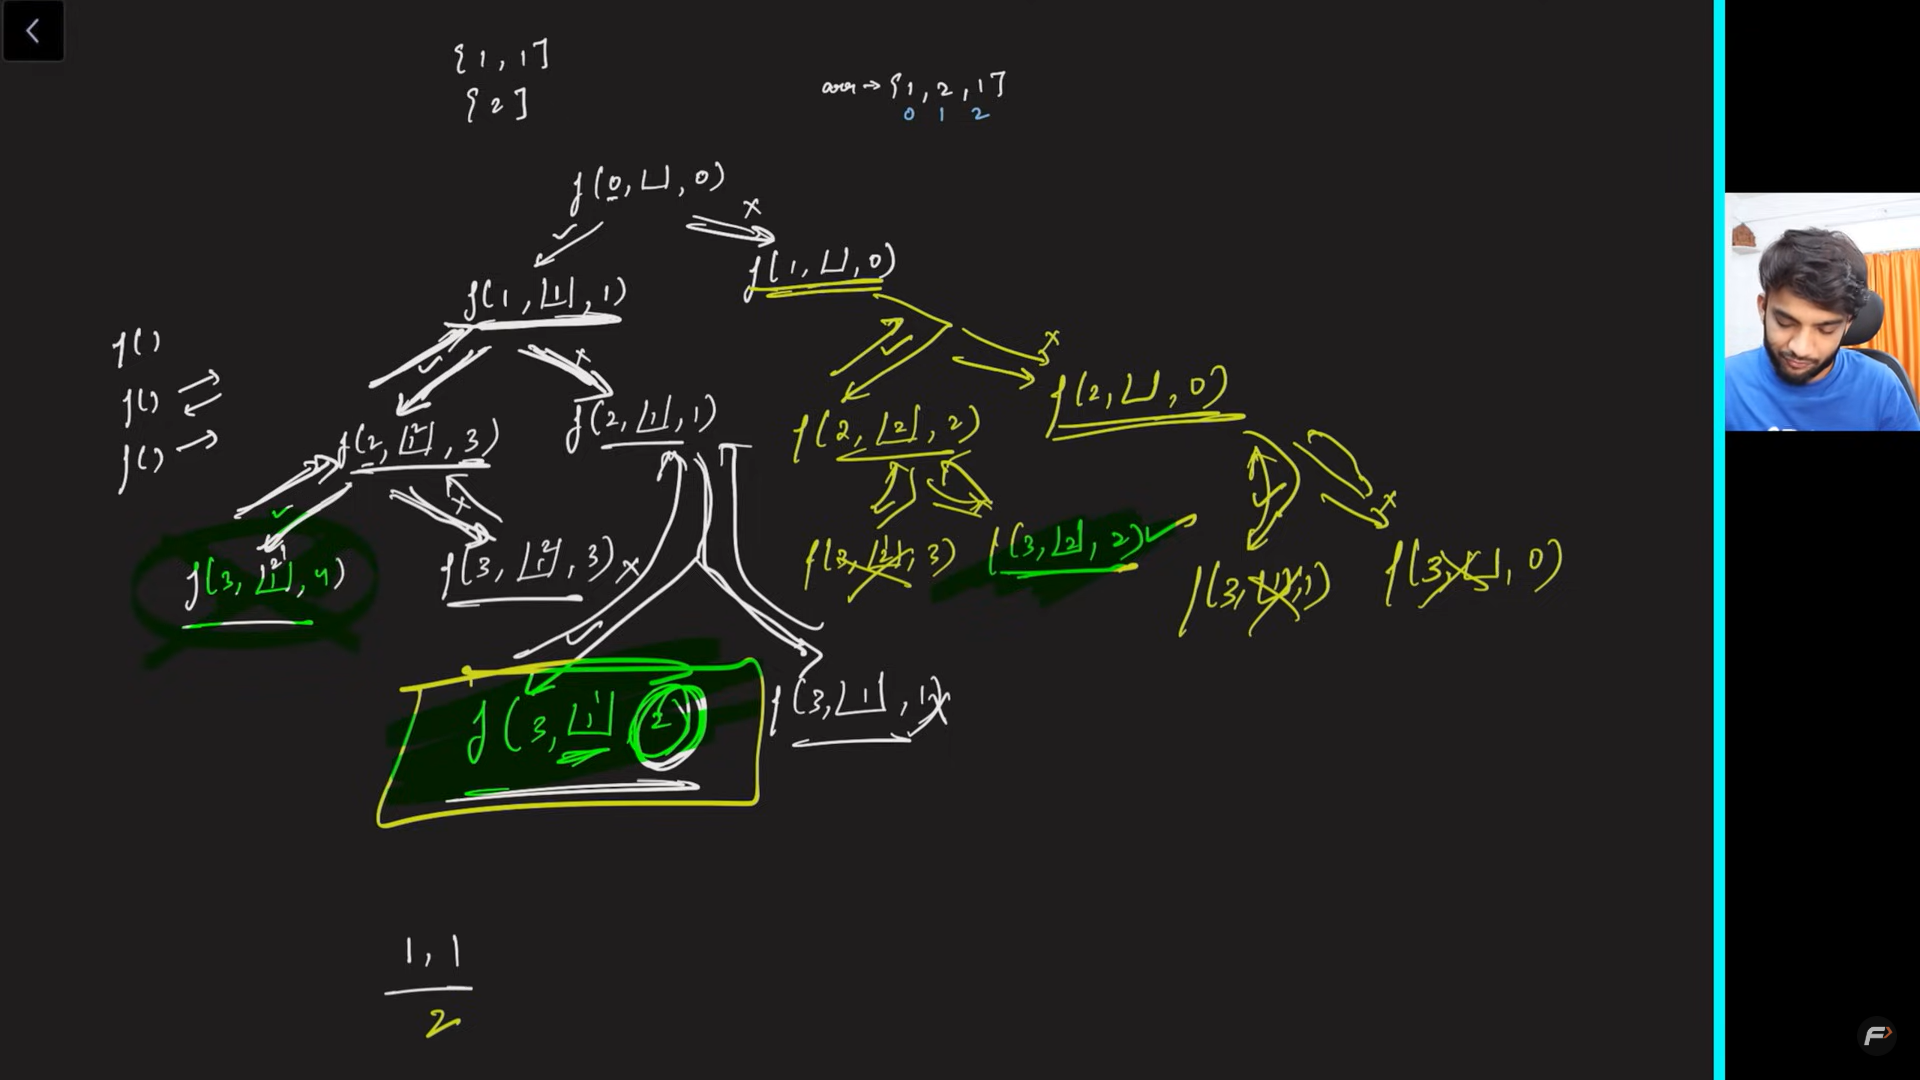

In [8]:
def generate_subsequence_equal_target(arr: list,
                                      idx: int,
                                      target: int,
                                      curr_sum: int,
                                      curr: list= None,
                                      ans: list= None):
    
    if curr is None:
        curr= []
    
    if ans is None:
        ans= []
    
    # base case
    if (idx == len(arr)):
        if (curr_sum == target):
            ans.append(curr[:])    # add copy of valid subsequence to the resulting array
        return
    
    # Pick case
    curr.append(arr[idx])
    curr_sum += arr[idx]        # add the current element to sum
    generate_subsequence_equal_target(arr, idx+1, target, curr_sum, curr, ans) 
    
    # Backtrack (undo everything)
    curr.pop()
    curr_sum -= arr[idx]    # remove the current element from sum
    
    # Not pick case
    generate_subsequence_equal_target(arr, idx+1, target, curr_sum, curr, ans)  
    
    return ans

In [9]:
arr= [1,2,1]

ans= generate_subsequence_equal_target(arr= arr,
                                        idx= 0,
                                        target= 2,
                                        curr_sum= 0,
                                        curr= None,
                                        ans= None)

ans

[[1, 1], [2]]

#### 3. Print only 1 subsequence out of the 2 

Approach:
- If base case satisfied return True, if not return False
- Wrap recursive call inside if block and check if it is True

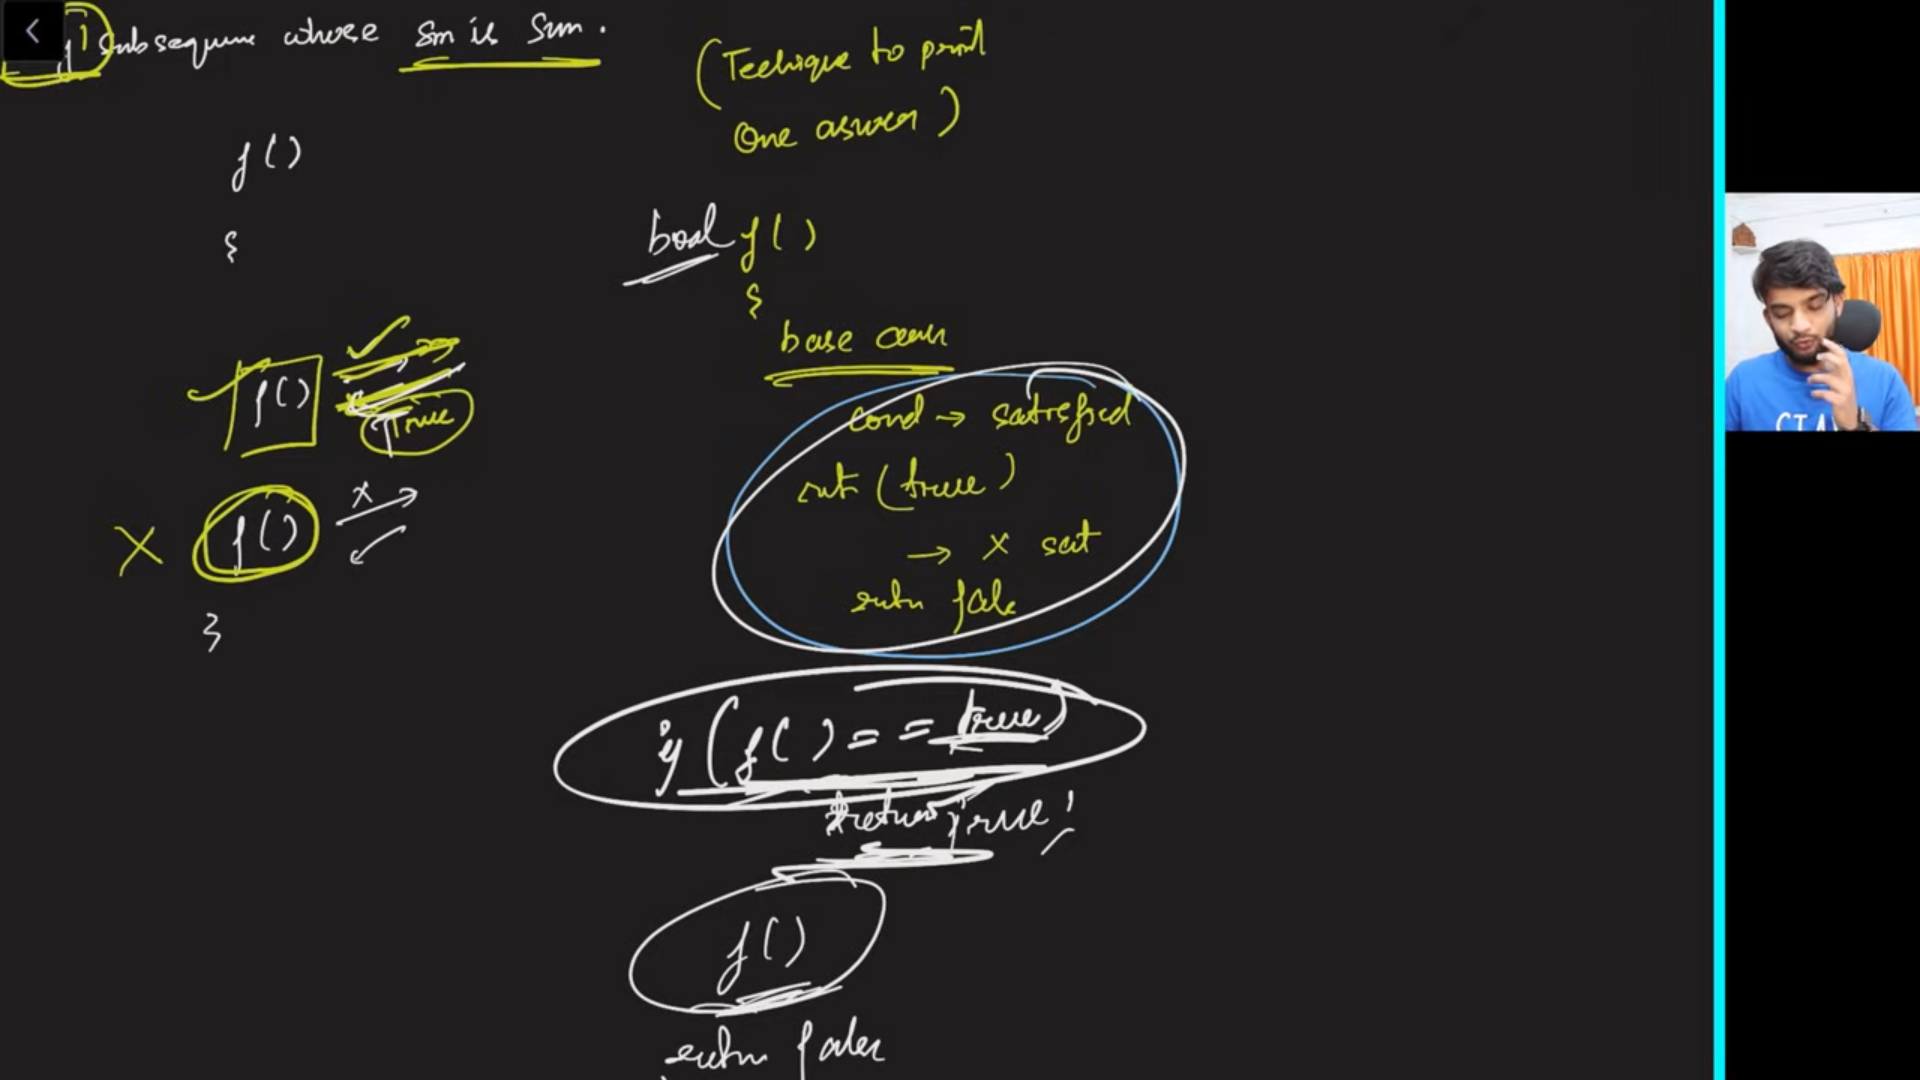

In [4]:
def generate_one_subsequence(arr: list,
                             idx: int, 
                             curr: list,
                             curr_sum: int,
                             target: int):
    
    if curr is None:
        curr= []
    
    # base case
    if (idx >= len(arr)):
        if curr_sum == target: # base case satisfied
            print(curr)
            return True 
        
        else:
            return False # base case not satisfied
        
    
    # Take case
    curr.append(arr[idx])
    curr_sum += arr[idx]
    
    # recursive call
    if (generate_one_subsequence(arr, idx+1, curr, curr_sum, target) == True):
        return True 
    
    # backtrack (undo the change)
    curr.pop()
    curr_sum -= arr[idx]
    
    # not take case
    if (generate_one_subsequence(arr, idx+1, curr, curr_sum, target) == True):
        return True 
    
    return False

In [3]:
arr= [1,2,1]

ans= generate_one_subsequence(arr= arr,
                                idx= 0,
                                target= 2,
                                curr_sum= 0,
                                curr= None)

[1, 1]


#### 4. Count the number of subsequences

Approach:
- If base case satisfied return 1, else 0
- Keep all the recursion calls in a variable
- At the end return the sum of all the recursion calls made (all the things you tried)

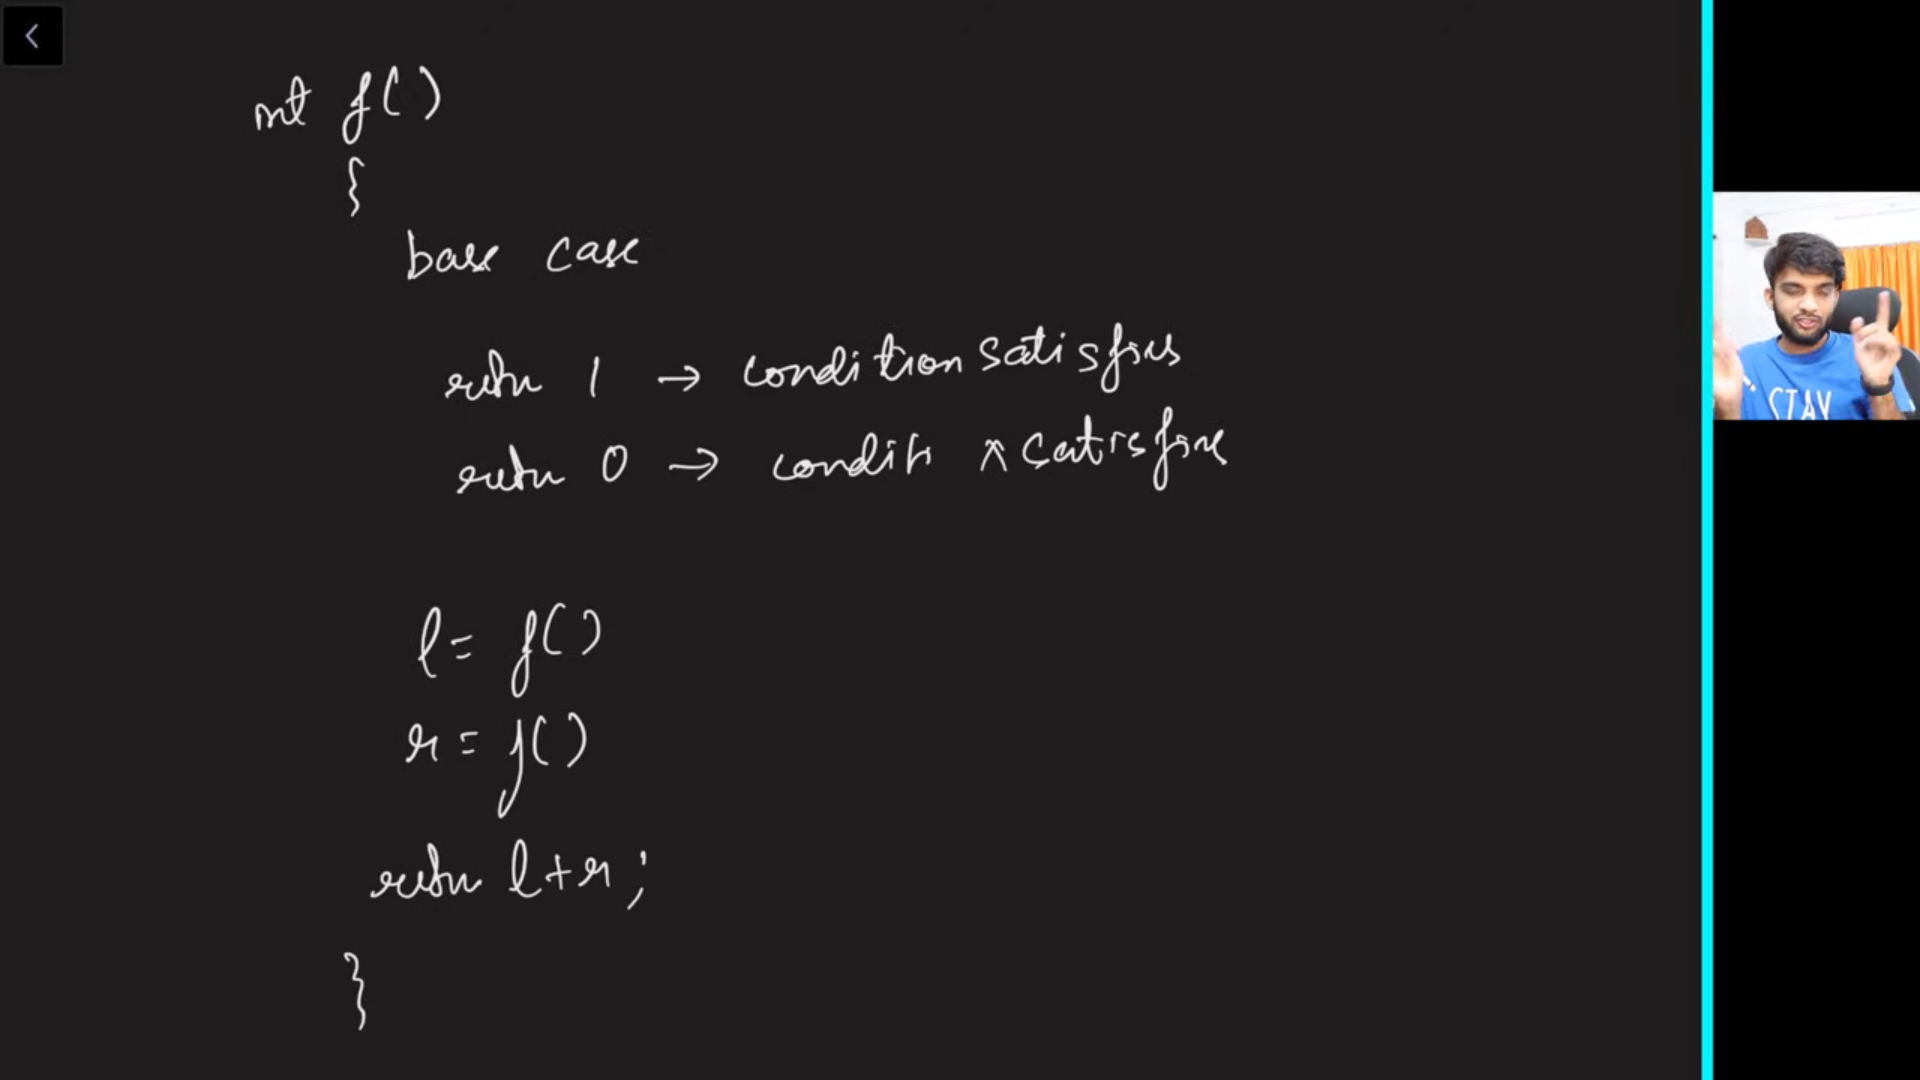

In [5]:
def count_subsequence_target(arr: list,
                             idx: int,
                             curr_sum: int,
                             curr: list,
                             target: int):
    
    if curr is None:
        curr= []
        
    # base case
    if (idx >= len(arr)):
        if (curr_sum == target):    # base case satisfied, therefore return 1
            return 1
        
        else:                       # base case not satisfied, therefore return 0
            return 0
        
    
    # Pick case
    curr.append(arr[idx])
    curr_sum += arr[idx]
    
    left= count_subsequence_target(arr, idx+1, curr_sum, curr, target)      # store the recursion call in a variable
    
    # backtrack (undo the changes)
    curr.pop()
    curr_sum -= arr[idx]
    
    # Not pick case
    right= count_subsequence_target(arr, idx+1, curr_sum, curr, target)     # store the recursion call in a variable
    
    return left+right   # return the sum of possible cases 

In [6]:
arr= [1,2,1]

ans= count_subsequence_target(arr= arr,
                                idx= 0,
                                target= 2,
                                curr_sum= 0,
                                curr= None)
ans

2